In [1]:
import torch
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

In [2]:
def predictive_entropy(output):
    mean_output = np.mean(output, axis=0)
    return -np.sum(mean_output * np.log(mean_output + 1e-10), axis=-1)

def mutual_information(output):
    mean_output = np.mean(output, axis=0)
    entropy = -np.sum(mean_output * np.log(mean_output + 1e-10), axis=-1)
    expected_entropy = -np.mean(np.sum(output * np.log(output + 1e-10), axis=-1), axis=0)
    return entropy - expected_entropy

In [ ]:
from medmnist import INFO
from medmnist import PathMNIST


info = INFO['pathmnist']

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True),
    v2.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

transform_train = v2.Compose([
    v2.ToImage(),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness=0.2),
    v2.ToDtype(torch.float32, scale = True),
    v2.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


In [ ]:
lr = 0.003
epoch = 50
batch_size = 128
milestones = [15,30,45]
gamma = 0.3
num_monte_carlo = 25
transform_form = transform
moped_state = False

In [ ]:
trainset = PathMNIST(split = "train", download = True, size = 28, transform = transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size = batch_size, shuffle = True, num_workers = 4, pin_memory=True)

valset = PathMNIST(split = "val", download = True, size = 28, transform = transform)
valloader = torch.utils.data.DataLoader(valset, batch_size = batch_size, shuffle = False, num_workers = 4, pin_memory=True)

testset = PathMNIST(split = "test", size = 28, download=True, transform = transform)
testloader = torch.utils.data.DataLoader(testset, batch_size = batch_size, shuffle = False, num_workers = 4, pin_memory=True)

classes = info['label']
print(f"class names: {classes}")

class names: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}


In [ ]:
from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss
const_bnn_prior_parameters = {
        "prior_mu": 0.0,
        "prior_sigma": 1.0,
        "posterior_mu_init": 0.0,
        "posterior_rho_init": -3.0,
        "type": "Reparameterization",  
        "moped_enable": moped_state, 
        "moped_delta": 0.5,
}
net = torchvision.models.resnet18(pretrained=True)
dnn_to_bnn(net, const_bnn_prior_parameters)
net.fc = nn.Linear(512, len(classes))
net = net.to(device)

[Parameter containing:
tensor([[[[ 6.9225e-02, -3.9772e-02,  4.0729e-02,  ..., -4.7711e-02,
           -1.9101e-01, -2.5375e-01],
          [-1.0872e-01, -1.2133e-02, -3.3170e-02,  ..., -5.4323e-02,
           -1.0385e-01, -1.5132e-01],
          [ 2.1037e-02,  6.8009e-02,  4.7053e-02,  ..., -2.0793e-02,
            4.7289e-02, -5.5797e-02],
          ...,
          [ 5.6663e-02, -1.9805e-01,  4.0611e-02,  ...,  8.9601e-03,
            3.8890e-02,  1.0176e-01],
          [ 1.4765e-02, -1.7657e-01,  4.7476e-03,  ...,  2.9894e-02,
            1.2657e-01,  1.1168e-01],
          [ 1.8613e-01,  6.4479e-02, -2.9915e-02,  ...,  3.6678e-02,
            6.6836e-03, -1.2311e-01]],

         [[-9.0066e-02, -1.9980e-02, -1.2459e-01,  ...,  8.5896e-02,
            2.7965e-02, -5.9679e-02],
          [-3.4130e-02, -9.7812e-02,  9.2953e-02,  ...,  1.6557e-02,
           -4.6448e-02,  1.4771e-01],
          [-5.3296e-02, -1.5510e-01,  4.8647e-03,  ..., -1.5958e-01,
           -8.4878e-02,  4.8788e-02

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=lr)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=gamma)

In [8]:
train_losses = []
val_losses = []

for epoch in range(epoch):

    net.train()
    running_train_loss = 0.0

    for i, data in enumerate(trainloader, 0):

        images, labels = data[0].to(device), data[1].to(device)
        labels = labels.squeeze(1)

        optimizer.zero_grad()
        outputs = net(images)
        kl = get_kl_loss(net)

        ce_loss = criterion(outputs, labels)
        train_loss = ce_loss + kl / batch_size
        train_loss.backward()

        optimizer.step()
        running_train_loss += train_loss.item()

    scheduler.step()

    net.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for data in valloader:

            images, labels = data[0].to(device), data[1].to(device)
            labels = labels.squeeze(1)

            outputs = net(images)

            val_loss = criterion(outputs, labels)
            running_val_loss += val_loss.item()

    epoch_train_loss = running_train_loss / len(trainloader)
    epoch_val_loss = running_val_loss / len(valloader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    print(f'[epoch {epoch + 1}] train_loss : {epoch_train_loss:.3f} | val_loss : {epoch_val_loss:.3f}')

print('fini')


[epoch 1] train_loss : 1.607 | val_loss : 2.817
[epoch 2] train_loss : 1.507 | val_loss : 1.051
[epoch 3] train_loss : 1.370 | val_loss : 1.013
[epoch 4] train_loss : 1.310 | val_loss : 0.971
[epoch 5] train_loss : 1.267 | val_loss : 0.903
[epoch 6] train_loss : 1.243 | val_loss : 0.938
[epoch 7] train_loss : 1.221 | val_loss : 0.897
[epoch 8] train_loss : 1.199 | val_loss : 0.998
[epoch 9] train_loss : 1.176 | val_loss : 0.973
[epoch 10] train_loss : 1.150 | val_loss : 0.850
[epoch 11] train_loss : 1.130 | val_loss : 0.830
[epoch 12] train_loss : 1.113 | val_loss : 0.806
[epoch 13] train_loss : 1.111 | val_loss : 0.865
[epoch 14] train_loss : 1.088 | val_loss : 0.836
[epoch 15] train_loss : 1.077 | val_loss : 0.747
[epoch 16] train_loss : 1.068 | val_loss : 0.757
[epoch 17] train_loss : 1.045 | val_loss : 0.772
[epoch 18] train_loss : 1.044 | val_loss : 0.947
[epoch 19] train_loss : 1.042 | val_loss : 0.739
[epoch 20] train_loss : 1.030 | val_loss : 0.726
[epoch 21] train_loss : 0.995

In [ ]:
torch.save(net.state_dict(), "./pathmnist_bnn.pth")

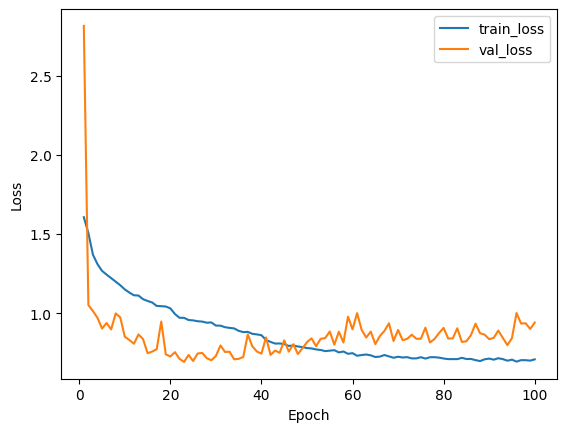

In [9]:
plt.plot(range(1, len(train_losses) + 1), train_losses, label='train_loss')
plt.plot(range(1, len(val_losses) + 1),   val_losses,   label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [10]:
correct = 0
total = 0
net.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        labels = labels.squeeze(1)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Précision : {100 * correct / total:.1f}%')

Précision : 74.6%


In [11]:
net.eval()

all_outputs = []
all_labels = []
all_predicted = []

with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        labels = labels.squeeze(1)
        output_mc = []

        for mc_run in range(num_monte_carlo):
            outputs = net(images)
            probs = torch.nn.functional.softmax(outputs, dim=-1)
            output_mc.append(probs)

        output = torch.stack(output_mc)  
        pred_mean = output.mean(dim=0)
        y_pred = torch.argmax(pred_mean, axis=-1)

        all_outputs.append(output.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_predicted.append(y_pred.cpu().numpy())

    all_outputs   = np.concatenate(all_outputs,   axis=1)
    all_labels    = np.concatenate(all_labels,    axis=0)
    all_predicted = np.concatenate(all_predicted, axis=0)

    test_acc = (all_labels == all_predicted).mean()
    print(f'Précision : {100*test_acc:.2f}%')

Précision : 78.00%


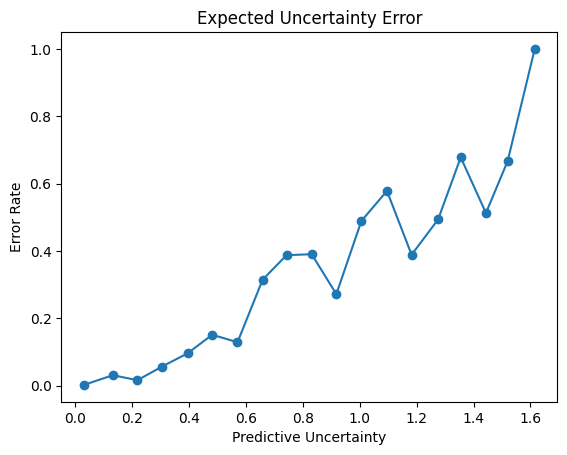

In [12]:
predictive_uncertainty = predictive_entropy(all_outputs)
errors = (all_predicted != all_labels).astype(float)

n_bins = 20
bins = np.linspace(predictive_uncertainty.min(), predictive_uncertainty.max(), n_bins)
bin_idx = np.digitize(predictive_uncertainty, bins)

bin_uncertainty = []
bin_error = []
for b in range(1, n_bins):
    mask = bin_idx == b
    if mask.sum() > 0:
        bin_uncertainty.append(predictive_uncertainty[mask].mean())
        bin_error.append(errors[mask].mean())

plt.plot(bin_uncertainty, bin_error, marker='o')
plt.xlabel('Predictive Uncertainty')
plt.ylabel("Error Rate")
plt.title('Expected Uncertainty Error')
plt.show()



ECE : 2.29%


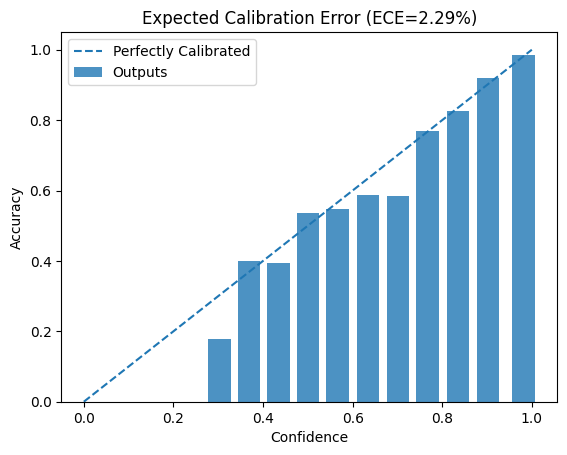

In [ ]:
mean_probs = all_outputs.mean(axis=0) 
confidences = mean_probs.max(axis=-1)  
correct = (all_predicted == all_labels).astype(float)

n_bins = 15
bin_boundaries = np.linspace(0, 1, n_bins + 1)
bin_acc = []
bin_conf = []
bin_sizes = []

for i in range(n_bins):
    mask = (confidences >= bin_boundaries[i]) & (confidences < bin_boundaries[i+1])
    if mask.sum() > 0:
        bin_acc.append(correct[mask].mean())
        bin_conf.append(confidences[mask].mean())
        bin_sizes.append(mask.sum())

ece = sum(s * abs(a - c) for s, a, c in zip(bin_sizes, bin_acc, bin_conf)) / len(all_labels)
print(f'ECE : {100*ece:.2f}%')

In [ ]:
class_names = list(classes.values())
correct_pred = {classname: 0 for classname in class_names}
total_pred   = {classname: 0 for classname in class_names}

with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        labels = labels.squeeze(1)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        for label, prediction in zip(labels, predictions):
            name = classes[str(label.item())]
            if label == prediction:
                correct_pred[name] += 1
            total_pred[name] += 1

for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: actinic keratoses and intraepithelial carcinoma is 37.9 %
Accuracy for class: basal cell carcinoma is 53.4 %
Accuracy for class: benign keratosis-like lesions is 43.6 %
Accuracy for class: dermatofibroma is 21.7 %
Accuracy for class: melanoma is 38.1 %
Accuracy for class: melanocytic nevi is 89.9 %
Accuracy for class: vascular lesions is 51.7 %


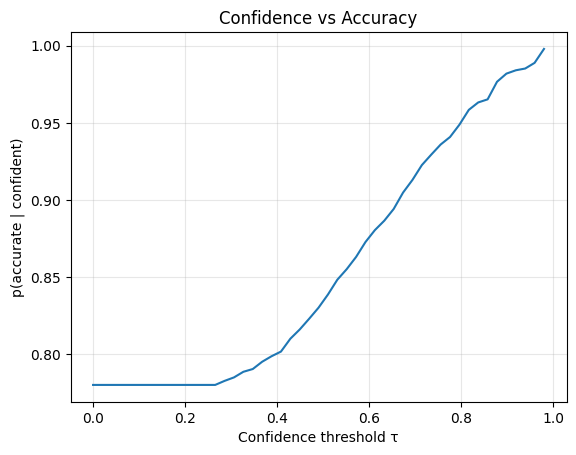

In [15]:
thresholds = np.linspace(0, 1, 50)
p_accurate_given_certain = []

for t in thresholds:
    mask = mean_probs.max(axis=-1) >= t  # prédictions avec confiance >= t
    if mask.sum() > 0:
        p_accurate_given_certain.append((all_predicted[mask] == all_labels[mask]).mean())
    else:
        p_accurate_given_certain.append(np.nan)

plt.plot(thresholds, p_accurate_given_certain)
plt.xlabel("Confidence threshold τ")
plt.ylabel("p(accurate | confident)")
plt.title("Confidence vs Accuracy")
plt.grid(True, alpha=0.3)
plt.show()

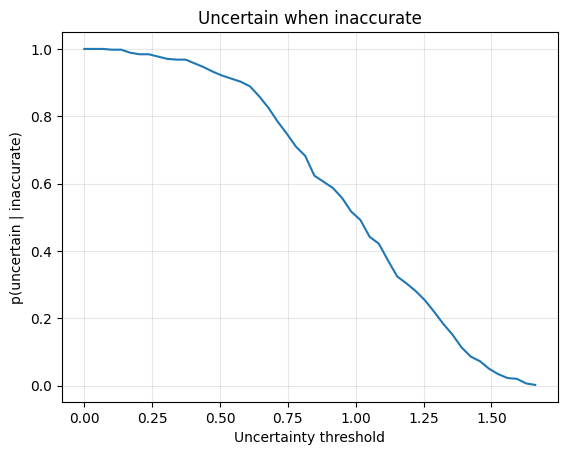

In [16]:
thresholds_u = np.linspace(0, predictive_uncertainty.max(), 50)
p_uncertain_given_inaccurate = []

inaccurate_mask = all_predicted != all_labels

for t in thresholds_u:
    if inaccurate_mask.sum() > 0:
        p_uncertain_given_inaccurate.append(
            (predictive_uncertainty[inaccurate_mask] >= t).mean()
        )
    else:
        p_uncertain_given_inaccurate.append(np.nan)

plt.plot(thresholds_u, p_uncertain_given_inaccurate)
plt.xlabel("Uncertainty threshold")
plt.ylabel("p(uncertain | inaccurate)")
plt.title("Uncertain when inaccurate")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.drawing.image import Image as XLImage
from datetime import datetime
import os
import matplotlib.pyplot as plt
import io

def make_chart_buf(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    plt.close(fig)
    buf.seek(0)
    return buf

def save_results(
    lr, epoch, milestones, gamma, moped_state,
    test_acc, ece,
    bin_uncertainty, bin_error,
    bin_conf, bin_acc, bin_sizes,
    conf_thresholds, p_accurate_given_certain,
    uncertainty_thresholds, p_uncertain_given_inaccurate,
    filename="resultats_pathmnist.xlsx"
):
    header_font = Font(bold=True, color="FFFFFF", name="Arial")
    header_fill = PatternFill("solid", start_color="2F4F8F")
    normal_font = Font(name="Arial")
    center      = Alignment(horizontal="center")

    def set_header(cell, value):
        cell.value = value
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = center

    def set_col_width(ws, col, width):
        ws.column_dimensions[openpyxl.utils.get_column_letter(col)].width = width

    #  Charger ou créer le fichier 
    if os.path.exists(filename):
        wb = openpyxl.load_workbook(filename)
    else:
        wb = openpyxl.Workbook()
        wb.active.title = "Runs"

    if "Runs" not in wb.sheetnames:
        ws = wb.create_sheet("Runs", 0)
    else:
        ws = wb["Runs"]

    # Générer un run_id 
    if ws.cell(1, 1).value is None:
        run_id = 1
    else:
        run_id = ws.max_row

    # Feuille 1 : Runs
    headers = [
        "Run ID", "lr",
        "milestones", "gamma", "moped_state",
        "accuracy (%)", "ECE (%)"
    ]

    if ws.cell(1, 1).value is None:
        for col, h in enumerate(headers, start=1):
            set_header(ws.cell(1, col), h)
        for col in range(1, len(headers) + 1):
            set_col_width(ws, col, 20)

    row = ws.max_row + 1
    values = [
        run_id,
        datetime.now().strftime("%Y-%m-%d %H:%M"),
        lr, epoch, batch_size, str(milestones), gamma, num_monte_carlo, moped_state,
        round(100 * test_acc, 2),
        round(100 * ece, 2),
    ]
    for col, val in enumerate(values, start=1):
        ws.cell(row, col, val).font = normal_font

    # Feuille 2 : Détails du run
    ws2 = wb.create_sheet(f"Run_{run_id}")

    # EUE (colonne 5)
    set_header(ws2.cell(1, 34), "EUE - Uncertainty")
    set_header(ws2.cell(1, 35), "EUE - Error rate")
    set_col_width(ws2, 34, 20)
    set_col_width(ws2, 35, 20)

    for i, (u, e) in enumerate(zip(bin_uncertainty, bin_error), start=2):
        ws2.cell(i, 34, round(float(u), 4)).font = normal_font
        ws2.cell(i, 35, round(float(e), 4)).font = normal_font

    # Confidence vs Accuracy
    set_header(ws2.cell(1, 40), "Confidence Threshold")
    set_header(ws2.cell(1, 41), "p(accurate | confident)")
    set_col_width(ws2, 40, 18)
    set_col_width(ws2, 41, 22)
    for i, (t, p) in enumerate(zip(conf_thresholds, p_accurate_given_certain), start=2):
        ws2.cell(i, 40, round(float(t), 4)).font = normal_font
        if not (p != p):  # NaN check
            ws2.cell(i, 41, "N/A").font = normal_font

    # Uncertain when inaccurate
    set_header(ws2.cell(1, 43), "Uncertainty Threshold")
    set_header(ws2.cell(1, 44), "p(uncertain | inaccurate)")
    set_col_width(ws2, 43, 18)
    set_col_width(ws2, 44, 24)
    for i, (t, p) in enumerate(zip(uncertainty_thresholds, p_uncertain_given_inaccurate), start=2):
        ws2.cell(i, 43, round(float(t), 4)).font = normal_font
        if not (p != p):  # NaN check
            ws2.cell(i, 44, "N/A").font = normal_font

    # Graphiques
    epochs_range = list(range(1, len(train_losses) + 1))

    # Losses
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(epochs_range, train_losses, label="Train Loss", color="steelblue")
    ax.plot(epochs_range, val_losses,   label="Val Loss",   color="orange")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Run {run_id} — Train & Val Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    img_loss = XLImage(make_chart_buf(fig))
    img_loss.anchor = "A1"
    ws2.add_image(img_loss)

    # EUE
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot([float(u) for u in bin_uncertainty], [float(e) for e in bin_error], marker='o', color="steelblue")
    ax.set_xlabel("Incertitude prédictive")
    ax.set_ylabel("Taux d'erreur")
    ax.set_title(f"Run {run_id} — Expected Uncertainty Error")
    ax.grid(True, alpha=0.3)
    img_eue = XLImage(make_chart_buf(fig))
    img_eue.anchor = "H1"
    ws2.add_image(img_eue)

    # ECE reliability diagram
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar([float(c) for c in bin_conf], [float(a) for a in bin_acc], width=0.05, alpha=0.8, label="Outputs")
    ax.plot([0, 1], [0, 1], '--', color='gray', label="Parfait")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Run {run_id} — Reliability Diagram (ECE={round(100*ece,2)}%)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    img_ece = XLImage(make_chart_buf(fig))
    img_ece.anchor = "Q1"
    ws2.add_image(img_ece)

    # Confidence vs Accuracy
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(conf_thresholds, p_accurate_given_certain, color="steelblue")
    ax.set_xlabel("Confidence Threshold")
    ax.set_ylabel("p(accurate | confident)")
    ax.set_title(f"Run {run_id} — Confidence vs Accuracy")
    ax.grid(True, alpha=0.3)
    img_cva = XLImage(make_chart_buf(fig))
    img_cva.anchor = "A25"
    ws2.add_image(img_cva)

    # Uncertain when inaccurate
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(uncertainty_thresholds, p_uncertain_given_inaccurate, color="orange")
    ax.set_xlabel("Uncertainty Threshold")
    ax.set_ylabel("p(uncertain | inaccurate)")
    ax.set_title(f"Run {run_id} — Uncertain when Inaccurate")
    ax.grid(True, alpha=0.3)
    img_uwi = XLImage(make_chart_buf(fig))
    img_uwi.anchor = "H25"
    ws2.add_image(img_uwi)

    wb.save(filename)
    print(f"Run {run_id} sauvegardé dans : {filename}")


# ── Appel ─────────────────────────────────────────────────────
save_results(
    lr=lr,
    epoch=epoch,
    batch_size=batch_size,
    milestones=milestones,
    gamma=gamma,
    num_monte_carlo=num_monte_carlo,
    test_acc=test_acc,
    ece=ece,
    train_losses=train_losses,
    val_losses=val_losses,
    bin_uncertainty=bin_uncertainty,
    bin_error=bin_error,
    bin_conf=bin_conf,
    bin_acc=bin_acc,
    bin_sizes=bin_sizes,
    conf_thresholds=thresholds,
    p_accurate_given_certain=p_accurate_given_certain,
    uncertainty_thresholds=thresholds_u,
    p_uncertain_given_inaccurate=p_uncertain_given_inaccurate,
    moped_state=moped_state,
    filename="resultats_pathmnist.xlsx"
)

Run 24 sauvegardé dans : resultats_dermamnist.xlsx
